# Proyek Deep Learning: Klasifikasi Kemiskinan
**Kelompok 11**

## 1. Import Libraries
Bagian ini memuat semua library Python yang dibutuhkan untuk analisis data, visualisasi, dan pemodelan ANN.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 2. Load Dataset
Membaca dataset CSV ke dalam DataFrame Pandas.

In [2]:
df = pd.read_csv('Klasifikasi_Kemiskinan.csv')

## 3. Data Exploration & Cleaning
Memeriksa tipe data, statistik deskriptif, baris duplikat, dan nilai kosong (missing values).

In [3]:
# Menampilkan informasi dataset
print("Info Dataset:")
print(df.info())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 13 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Provinsi                                                              514 non-null    object 
 1   Kab/Kota                                                              514 non-null    object 
 2   Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)       514 non-null    float64
 3   Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                           514 non-null    float64
 4   Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)          514 non-null    int64  
 5   Indeks Pembangunan Manusia                                            514 non-null    float64
 6   Umur Harapan Hidup (Tahun)                                            514 non-null  

In [4]:
# Menampilkan 5 baris pertama
print("\nStatistik Deskriptif:")
display(df.describe())


Statistik Deskriptif:


,Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),Rata-rata Lama Sekolah Penduduk 15+ (Tahun),Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),Indeks Pembangunan Manusia,Umur Harapan Hidup (Tahun),Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,Persentase rumah tangga yang memiliki akses terhadap air minum layak,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah),Klasifikasi Kemiskinan
count,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,5.140000e+02,514.000000
mean,12.273152,8.436615,10324.787938,69.926770,69.656809,77.202237,85.136615,5.059494,69.464455,2.196408e+07,0.120623
std,7.458703,1.630842,2717.144186,6.497033,3.447464,18.583555,15.701658,2.636970,6.396405,4.790492e+07,0.326005
min,2.380000,1.420000,3976.000000,32.840000,55.430000,0.000000,0.000000,0.000000,56.390000,1.474850e+05,0.000000
25%,7.150000,7.510000,8574.000000,66.642500,67.387500,70.217500,79.042500,3.180000,65.070000,3.654292e+06,0.000000
50%,10.455000,8.305000,10196.500000,69.610000,69.975000,81.800000,89.795000,4.565000,68.955000,8.814926e+06,0.000000
75%,14.887500,9.337500,11719.000000,73.112500,72.042500,89.882500,96.400000,6.530000,72.342500,1.973510e+07,0.000000
max,41.660000,12.830000,23888.000000,87.180000,77.730000,99.970000,100.000000,13.370000,97.930000,4.600810e+08,1.000000


In [5]:
display(df.head())

,Provinsi,Kab/Kota,Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),Rata-rata Lama Sekolah Penduduk 15+ (Tahun),Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),Indeks Pembangunan Manusia,Umur Harapan Hidup (Tahun),Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,Persentase rumah tangga yang memiliki akses terhadap air minum layak,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah),Klasifikasi Kemiskinan
0,ACEH,Simeulue,18.98,9.48,7148,66.41,65.28,71.56,87.45,5.71,71.15,1648096,0
1,ACEH,Aceh Singkil,20.36,8.68,8776,69.22,67.43,69.56,78.58,8.36,62.85,1780419,1
2,ACEH,Aceh Selatan,13.18,8.88,8180,67.44,64.40,62.55,79.65,6.46,60.85,4345784,0
3,ACEH,Aceh Tenggara,13.41,9.67,8030,69.44,68.22,62.71,86.71,6.43,69.62,3487157,0
4,ACEH,Aceh Timur,14.45,8.21,8577,67.83,68.74,66.75,83.16,7.13,59.48,8433526,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

Provinsi                                                                0
Kab/Kota                                                                0
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)         0
Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                             0
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)            0
Indeks Pembangunan Manusia                                              0
Umur Harapan Hidup (Tahun)                                              0
Persentase rumah tangga yang memiliki akses terhadap sanitasi layak     0
Persentase rumah tangga yang memiliki akses terhadap air minum layak    0
Tingkat Pengangguran Terbuka                                            0
Tingkat Partisipasi Angkatan Kerja                                      0
PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)              0
Klasifikasi Kemiskinan                                                  0
dtype: int64

## 4. Exploratory Data Analysis (EDA)
Menganalisis korelasi antar variabel dan pola data kemiskinan di Indonesia.

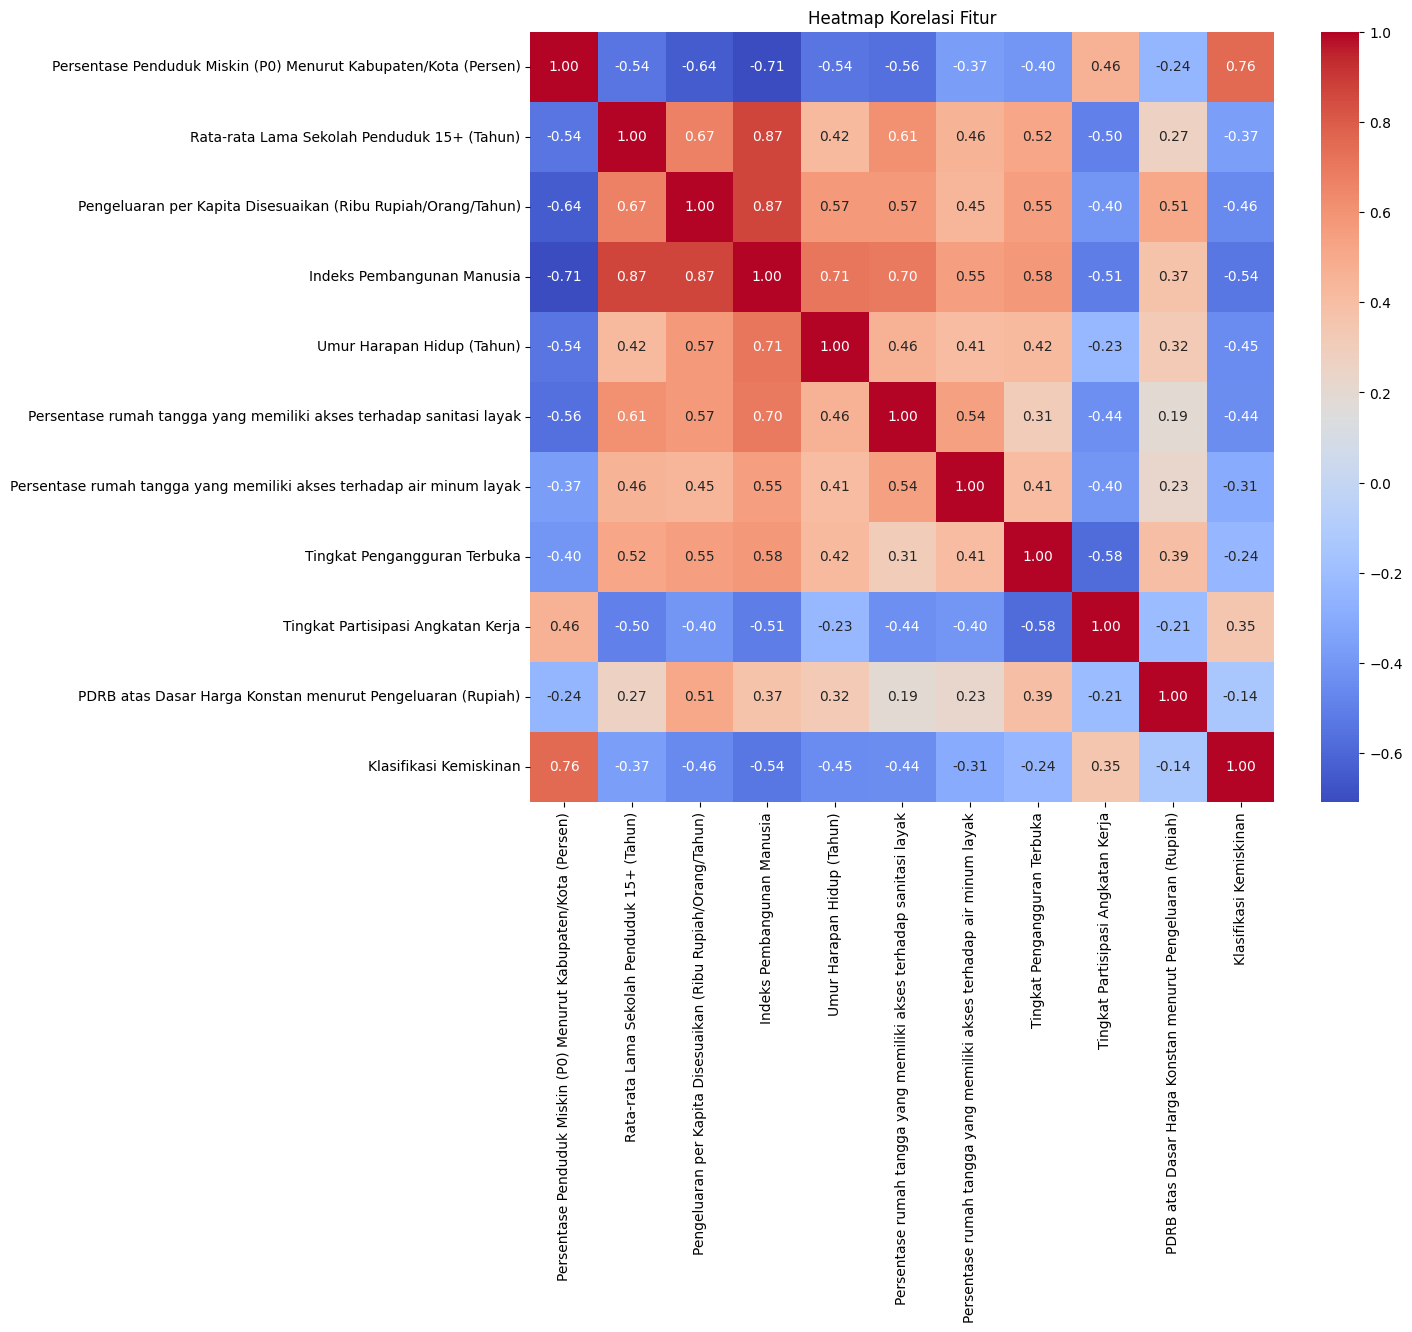

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Menghitung matriks korelasi
plt.figure(figsize=(12, 10))
correlation_matrix = df.drop(['Provinsi', 'Kab/Kota'], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur')
plt.show()

C:\Users\AZZAM FARRAS RUSLANI\AppData\Local\Temp\ipykernel_23780\3040676223.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Kab/Kota', y='Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',


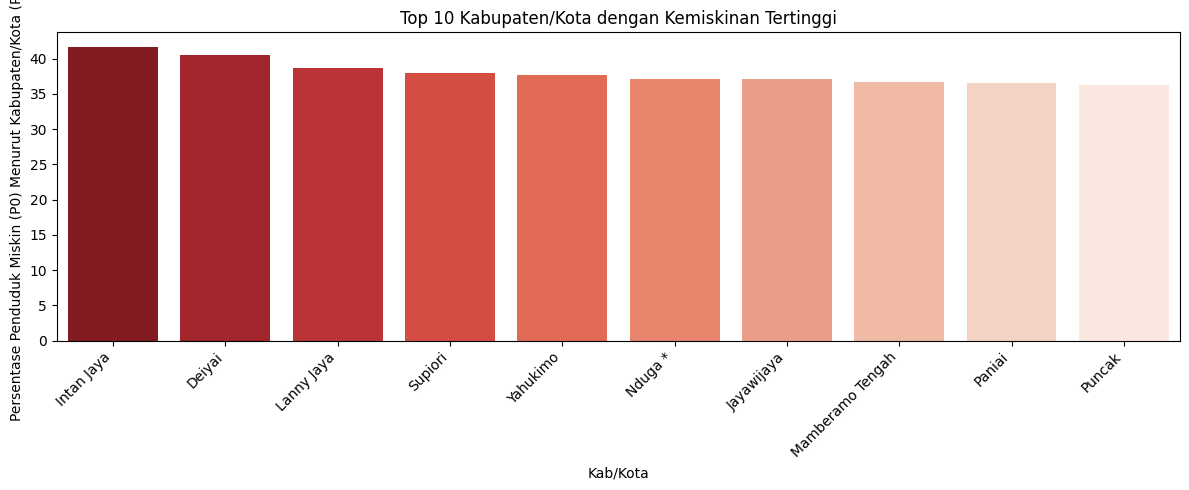

In [9]:
# Top 10 Kabupaten/Kota dengan Persentase Kemiskinan Tertinggi
top10 = df.nlargest(10, 'Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)')

plt.figure(figsize=(12, 5))
sns.barplot(x='Kab/Kota', y='Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
 data=top10, palette='Reds_r')
plt.title('Top 10 Kabupaten/Kota dengan Kemiskinan Tertinggi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Analisis Distribusi dan Karakteristik Fitur
Bagian ini bertujuan untuk melihat sebaran data pada setiap indikator serta membandingkan karakteristik daerah miskin vs tidak miskin.

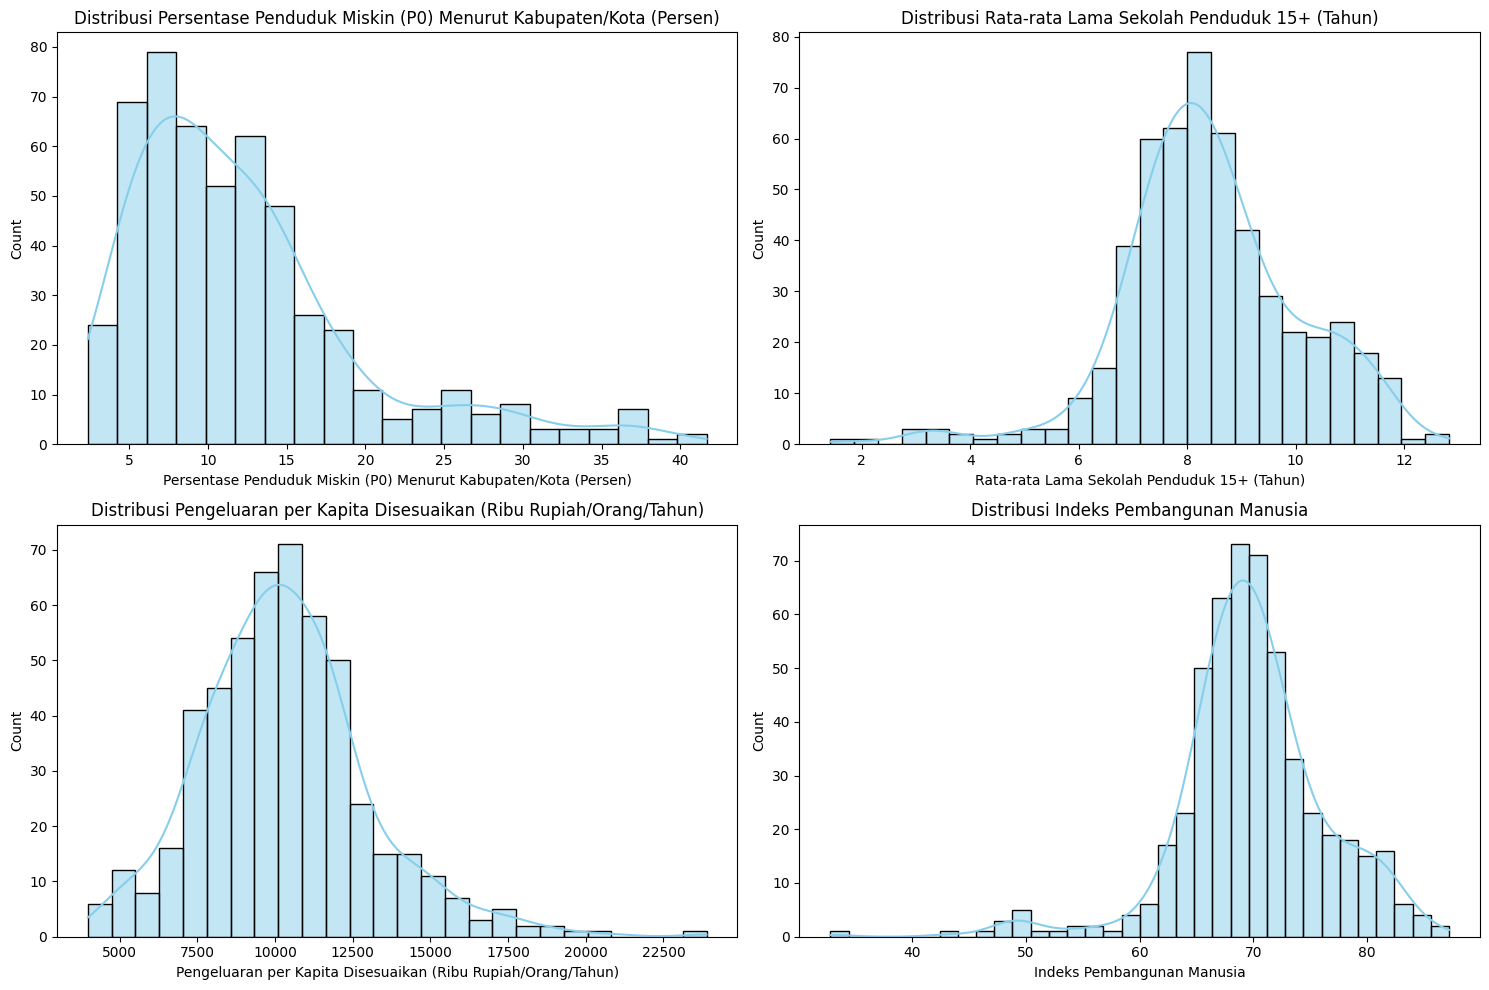

In [10]:
# Visualisasi distribusi untuk fitur-fitur utama
features_to_plot = ['Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
                    'Rata-rata Lama Sekolah Penduduk 15+ (Tahun)',
                    'Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)',
                    'Indeks Pembangunan Manusia']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

C:\Users\AZZAM FARRAS RUSLANI\AppData\Local\Temp\ipykernel_23780\3482577066.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Klasifikasi Kemiskinan', y=col, data=df, palette='Set2')
C:\Users\AZZAM FARRAS RUSLANI\AppData\Local\Temp\ipykernel_23780\3482577066.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Klasifikasi Kemiskinan', y=col, data=df, palette='Set2')
C:\Users\AZZAM FARRAS RUSLANI\AppData\Local\Temp\ipykernel_23780\3482577066.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Klasifikasi Kemiskinan', y=col, data=df,

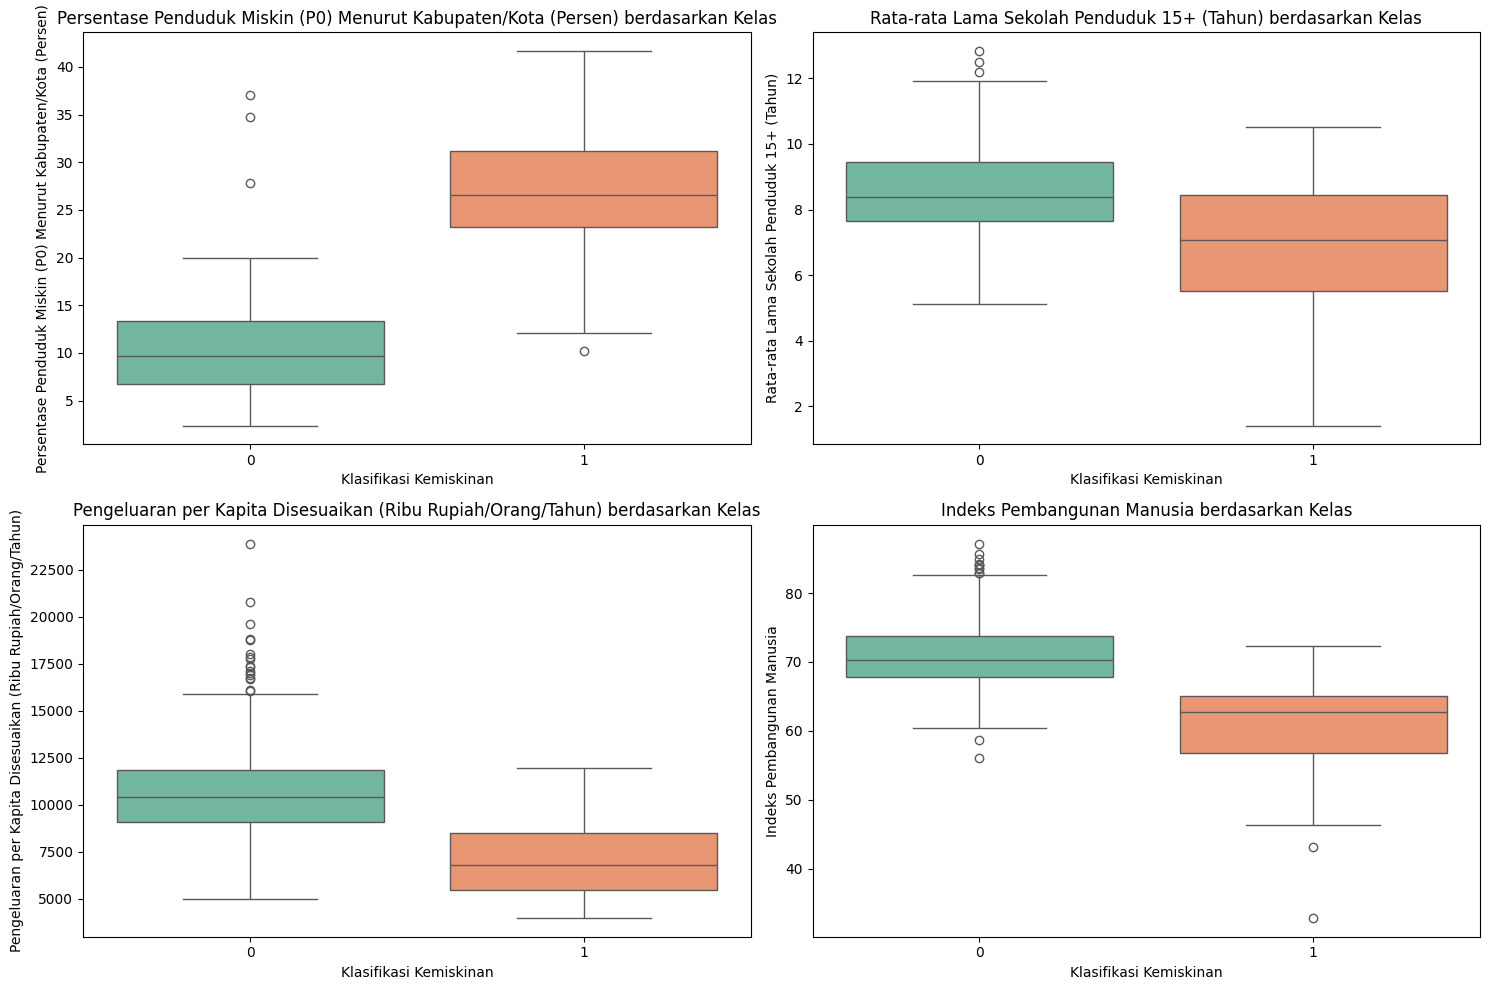

In [11]:
# Boxplot untuk melihat perbedaan nilai fitur berdasarkan Klasifikasi Kemiskinan
plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Klasifikasi Kemiskinan', y=col, data=df, palette='Set2')
    plt.title(f'{col} berdasarkan Kelas')

plt.tight_layout()
plt.show()

Distribusi Kelas Target:
Klasifikasi Kemiskinan
0    452
1     62
Name: count, dtype: int64

Persentase:
Klasifikasi Kemiskinan
0    87.937743
1    12.062257
Name: proportion, dtype: float64


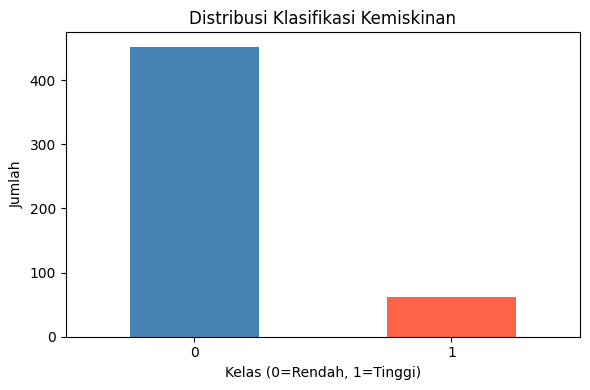

Jumlah per kelas:
Klasifikasi Kemiskinan
0    452
1     62
Name: count, dtype: int64


In [12]:
# Definisikan y dari kolom target sebelum dicek
y = df['Klasifikasi Kemiskinan']

# Mengecek keseimbangan kelas pada target
print("Distribusi Kelas Target:")
print(y.value_counts())
print("\nPersentase:")
print(y.value_counts(normalize=True) * 100)

# Distribusi Target (Klasifikasi Kemiskinan)
plt.figure(figsize=(6, 4))
df['Klasifikasi Kemiskinan'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Distribusi Klasifikasi Kemiskinan')
plt.xlabel('Kelas (0=Rendah, 1=Tinggi)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Jumlah per kelas:")
print(df['Klasifikasi Kemiskinan'].value_counts())

### Kesimpulan EDA
Berdasarkan visualisasi di atas, variabel **P0 (Persentase Penduduk Miskin)** dan **Pengeluaran per Kapita** menunjukkan perbedaan median dan rentang yang signifikan antara daerah Miskin (1) dan Tidak Miskin (0). Hal ini mengonfirmasi bahwa fitur-fitur tersebut merupakan prediktor yang sangat kuat untuk model klasifikasi.

## 5. Data Preprocessing
Melakukan penanganan ketidakseimbangan kelas (imbalance data) dengan SMOTE, pembagian data (split train-test), dan normalisasi fitur.

#### Data Augmentation (SMOTE)
Karena distribusi kelas target tidak seimbang (hanya ~12% data miskin), kita akan menggunakan SMOTE untuk menyeimbangkan dataset.

In [13]:
# Definisikan y dari kolom target sebelum dicek
y = df['Klasifikasi Kemiskinan']

# Mengecek keseimbangan kelas pada target
print("Distribusi Kelas Target:")
print(y.value_counts())
print("\nPersentase:")
print(y.value_counts(normalize=True) * 100)

Distribusi Kelas Target:
Klasifikasi Kemiskinan
0    452
1     62
Name: count, dtype: int64

Persentase:
Klasifikasi Kemiskinan
0    87.937743
1    12.062257
Name: proportion, dtype: float64


In [14]:
from imblearn.over_sampling import SMOTE

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Melakukan resampling pada fitur numerik
X_raw = df.drop(['Provinsi', 'Kab/Kota', 'Klasifikasi Kemiskinan'], axis=1)
y_raw = df['Klasifikasi Kemiskinan']

X_resampled, y_resampled = smote.fit_resample(X_raw, y_raw)

print(f'Ukuran data sebelum SMOTE: {X_raw.shape}')
print(f'Ukuran data setelah SMOTE: {X_resampled.shape}')
print('\nDistribusi target setelah SMOTE:')
print(y_resampled.value_counts(normalize=True) * 100)

Ukuran data sebelum SMOTE: (514, 10)
Ukuran data setelah SMOTE: (904, 10)

Distribusi target setelah SMOTE:
Klasifikasi Kemiskinan
0    50.0
1    50.0
Name: proportion, dtype: float64


In [15]:
# Membagi data hasil SMOTE menjadi Training dan Testing
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

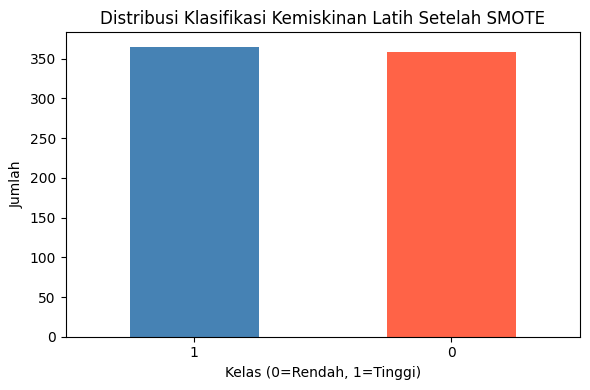

Jumlah per kelas target latih setelah SMOTE:
Klasifikasi Kemiskinan
1    365
0    358
Name: count, dtype: int64


In [16]:
# Visualisasi Distribusi Target Setelah SMOTE
import pandas as pd
import matplotlib.pyplot as plt
y_train_series = pd.Series(y_train)
plt.figure(figsize=(6, 4))
y_train_series.value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Distribusi Klasifikasi Kemiskinan Latih Setelah SMOTE')
plt.xlabel('Kelas (0=Rendah, 1=Tinggi)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("Jumlah per kelas target latih setelah SMOTE:")
print(y_train_series.value_counts())

In [17]:
# Scaling data menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data hasil SMOTE telah berhasil dipisahkan dan diskalakan.")
print(f"Ukuran X_train: {X_train_scaled.shape}")
print(f"Ukuran X_test: {X_test_scaled.shape}")

Data hasil SMOTE telah berhasil dipisahkan dan diskalakan.
Ukuran X_train: (723, 10)
Ukuran X_test: (181, 10)


## 6. Hyperparameter Tuning dengan Keras Tuner
Mencari kombinasi parameter ANN (jumlah neuron & nilai dropout) paling optimal menggunakan Bayesian Optimization.

In [18]:
# %pip install -q -U keras-tuner

In [19]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(hp):
    model = Sequential()
    # Tuning layer pertama
    model.add(Dense(
        units=hp.Int('units_1', min_value=16, max_value=64, step=16),
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    ))
    model.add(Dropout(hp.Float('dropout_1', 0.0, 0.5, step=0.1)))

    # Tuning layer kedua
    model.add(Dense(
        units=hp.Int('units_2', min_value=8, max_value=32, step=8),
        activation='relu'
    ))
    # Tuning dropout 2 sesuai permintaan Anda
    model.add(Dropout(hp.Float('dropout_2', 0.0, 0.5, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='kt_dir',
    project_name='poverty_tuning_v2',
    overwrite=True
)

tuner.search(X_train_scaled, y_train, epochs=50, validation_split=0.2, verbose=1)

Trial 10 Complete [00h 00m 10s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 01m 47s


In [20]:
# Mendapatkan hyperparameter terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Hyperparameters")
print(f"Units L1: {best_hps.get('units_1')}")
print(f"Dropout 1: {best_hps.get('dropout_1'):.2f}")
print(f"Units L2: {best_hps.get('units_2')}")
print(f"Dropout 2: {best_hps.get('dropout_2'):.2f}")
# Membangun model terbaik menggunakan learning rate yang ditemukan
model = tuner.hypermodel.build(best_hps)
# Menampilkan ringkasan arsitektur model terbaik
model.summary()

Best Hyperparameters
Units L1: 32
Dropout 1: 0.00
Units L2: 32
Dropout 2: 0.40


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Model Training & Evaluation
Melatih model ANN dengan hyperparameter terbaik dan mengevaluasi akurasi akhir pada data testing.

In [21]:
# Melatih model ANN
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\nProses pelatihan model selesai.")

# Evaluasi akhir
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f'\nAkurasi Model Akhir: {accuracy:.4f}')

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5606 - loss: 0.8285 - val_accuracy: 0.6897 - val_loss: 0.6298
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7716 - loss: 0.5597 - val_accuracy: 0.8621 - val_loss: 0.4810
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8806 - loss: 0.4131 - val_accuracy: 0.8828 - val_loss: 0.3786
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9031 - loss: 0.3348 - val_accuracy: 0.8897 - val_loss: 0.3097
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9204 - loss: 0.2751 - val_accuracy: 0.9172 - val_loss: 0.2640
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9239 - loss: 0.2410 - val_accuracy: 0.9172 - val_loss: 0.2319
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9273 - loss: 0.2129 - val_accuracy: 0.9172 - val_loss: 0.2071
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9394 - loss: 0.1931 - val_accuracy: 0.9172 - val_loss

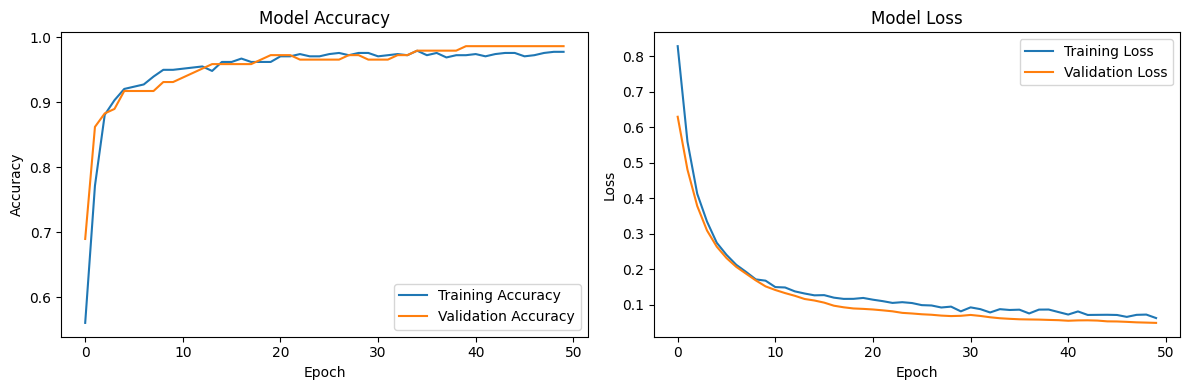

In [22]:
# Visualisasi History Pelatihan
plt.figure(figsize=(12, 4))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Confusion Matrix:


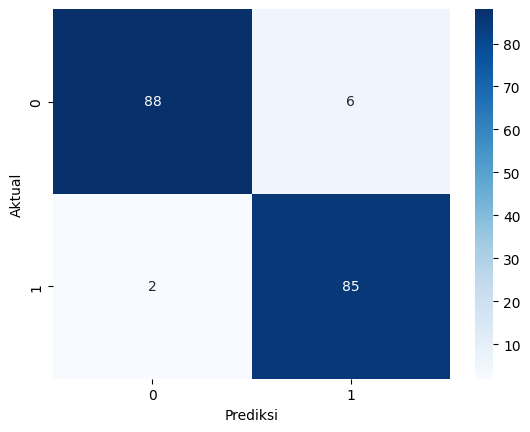


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        94
           1       0.93      0.98      0.96        87

    accuracy                           0.96       181
   macro avg       0.96      0.96      0.96       181
weighted avg       0.96      0.96      0.96       181



In [23]:
# Evaluasi Model pada Data Test
y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## 8. Feature Importance Analysis
Menganalisis fitur yang paling berpengaruh terhadap model klasifikasi kemiskinan berdasarkan rata-rata nilai absolut bobot pada layer input (Dense layer pertama).

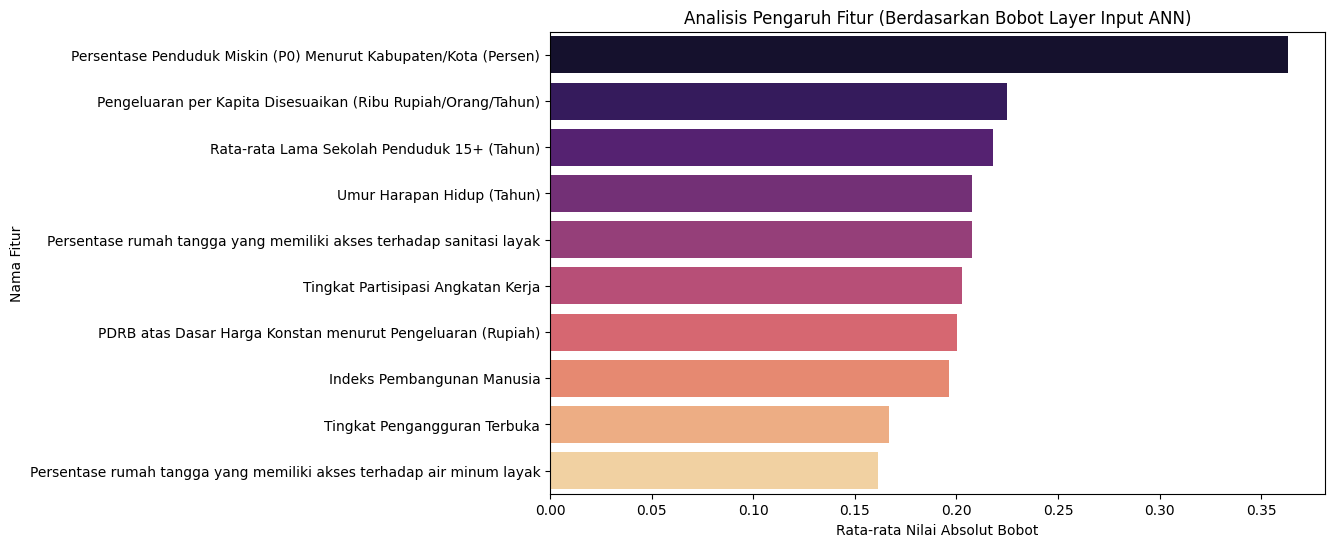

Fitur yang paling berpengaruh berdasarkan bobot model adalah:
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mengambil bobot dari layer pertama (Input ke Hidden Layer 1)
weights_first_layer = model.layers[0].get_weights()[0]

# Menghitung rata-rata nilai absolut bobot untuk setiap fitur
feature_importance = np.mean(np.abs(weights_first_layer), axis=1)

# Menyiapkan DataFrame
features = X_raw.columns
importance_df = pd.DataFrame({'Fitur': features, 'Kepentingan': feature_importance})
importance_df = importance_df.sort_values(by='Kepentingan', ascending=False)

# Visualisasi dengan perbaikan syntax untuk menghindari FutureWarning
plt.figure(figsize=(10, 6))
sns.barplot(x='Kepentingan', y='Fitur', data=importance_df, palette='magma', hue='Fitur', legend=False)
plt.title('Analisis Pengaruh Fitur (Berdasarkan Bobot Layer Input ANN)')
plt.xlabel('Rata-rata Nilai Absolut Bobot')
plt.ylabel('Nama Fitur')
plt.show()

print("Fitur yang paling berpengaruh berdasarkan bobot model adalah:")
print(importance_df.iloc[0]['Fitur'])


### Implementasi K-Fold Cross-Validation
Untuk memastikan konsistensi performa model, kita akan melakukan 5-Fold Cross-Validation menggunakan wrapper Scikit-Learn untuk Keras.

In [25]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Menyiapkan data (X_resampled sudah diskalakan secara utuh untuk CV)
scaler_cv = StandardScaler()
X_cv_scaled = scaler_cv.fit_transform(X_resampled)
y_cv = y_resampled.values

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print("Memulai Cross-Validation (5 Folds)...")

for i, (train, test) in enumerate(kfold.split(X_cv_scaled, y_cv)):
    # Membangun ulang arsitektur model yang sama
    model_cv = Sequential([
        Dense(64, activation='relu', input_shape=(X_cv_scaled.shape[1],)),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model_cv.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Latih model
    model_cv.fit(X_cv_scaled[train], y_cv[train], epochs=50, batch_size=32, verbose=0)

    # Evaluasi
    scores = model_cv.evaluate(X_cv_scaled[test], y_cv[test], verbose=0)
    print(f"Fold {i+1}: Accuracy = {scores[1]:.4f}")
    cv_scores.append(scores[1])

print(f"\nRata-rata Akurasi CV: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Memulai Cross-Validation (5 Folds)...


c:\Users\AZZAM FARRAS RUSLANI\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: Accuracy = 0.9448
Fold 2: Accuracy = 0.9669
Fold 3: Accuracy = 0.9779
Fold 4: Accuracy = 0.9724
Fold 5: Accuracy = 0.9722

Rata-rata Akurasi CV: 0.9668 (+/- 0.0116)


## 9. Export Model & Scaler
Menyimpan model terlatih (format Keras) dan objek scaler (format Pickle) agar dapat digunakan kembali oleh  web Streamlit.

In [26]:
# # EKSPOR MODEL (KERAS) & SCALER (PICKLE)
# import pickle
# import os

# # Memastikan folder Model ada
# os.makedirs('save_model', exist_ok=True)

# # 1. Simpan Scaler menggunakan format Pickle (.pkl)
# with open('save_model/scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)
# print("Scaler berhasil disimpan di 'save_model/scaler.pkl'")

# # 2. Simpan Model menggunakan format Keras (.keras)
# model.save('save_model/model_klasifikasi_kemiskinan.keras')
# print("Model Keras berhasil disimpan di 'save_model/model_klasifikasi_kemiskinan.keras'")

In [27]:
# BATCH TESTING - PREDIKSI BANYAK DATA SEKALIGUS

import pandas as pd
import numpy as np
import pickle
from tensorflow.keras.models import load_model

# 1. Load model dan scaler yang sudah disimpan
model = load_model('save_model/model_klasifikasi_kemiskinan.keras')
with open('save_model/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# 2. Load data baru yang ingin diuji (harus punya kolom fitur yang sama, tanpa kolom target)
data_baru = pd.read_csv('data_uji_baru.csv')

# Simpan kolom identitas (jika ada) untuk ditampilkan di hasil akhir
id_cols = [c for c in ['Provinsi', 'Kab/Kota'] if c in data_baru.columns]
identitas = data_baru[id_cols] if id_cols else pd.DataFrame(index=data_baru.index)

# Hapus kolom non-fitur sebelum scaling (sesuaikan dengan kolom yang dipakai saat training)
fitur_cols = [c for c in data_baru.columns if c not in ['Provinsi', 'Kab/Kota', 'Klasifikasi Kemiskinan']]
X_baru = data_baru[fitur_cols]

# 3. Scaling menggunakan scaler yang sudah di-fit saat training
X_baru_scaled = scaler.transform(X_baru)

# 4. Prediksi untuk seluruh baris data sekaligus
prob_pred = model.predict(X_baru_scaled)
y_pred = (prob_pred > 0.5).astype("int32").flatten()

# 5. Gabungkan hasil prediksi dengan data asli
hasil = identitas.copy()
hasil['Probabilitas_Miskin'] = prob_pred.flatten()
hasil['Prediksi_Kelas'] = y_pred
hasil['Keterangan'] = hasil['Prediksi_Kelas'].map({0: 'Tidak Miskin', 1: 'Miskin'})

print(f"Total data diuji: {len(hasil)}")
print(hasil)

# 6. (Opsional) Simpan hasil prediksi ke CSV
hasil.to_csv('hasil_prediksi_batch.csv', index=False)
print("\nHasil prediksi berhasil disimpan ke 'hasil_prediksi_batch.csv'")

FileNotFoundError: [Errno 2] No such file or directory: 'data_uji_baru.csv'